
# 01 — 数据集准备

## 两种数据源

### A) 合成 EHR 数据集 (默认, 推荐)
来源: `preprocessing/Final Project/` — Selective Retention 预处理管线
- **合成纵向 EHR 记录**: 300 个虚拟患者 × ~62 条医疗事件/人
- **QA 任务**: 诊断历史、用药追踪、不良反应+住院关联
- **Selective Retention**: 按事件重要性评分，保留 top 50% 高价值事件
- **离线生成，零依赖**: 不需要下载/联网，不需要真实患者数据
- **长上下文**: ~5000 字符/患者 → 适合测试 KV Cache 压力

### B) PubMedQA (可选)
来源: HuggingFace `qiaojin/PubMedQA` — 需要联网下载
- 医学文献摘要 QA，200-500 tokens/prompt


In [ ]:

import sys
sys.path.insert(0, '..')

from src.dataset_utils import (
    load_pubmedqa, load_dataset_auto,
    split_by_token_length, save_prompts,
)
from src.ehr_bridge import load_ehr_qa

# ---- 选择数据源 ----
# "ehr"      → 合成 EHR + selective retention (默认, 离线可用)
# "pubmedqa" → PubMedQA (需要联网)
DATA_SOURCE = "ehr"
EHR_STRATEGY = "selective"       # full_context | selective | sliding_window
EHR_RETENTION_RATIO = 0.5       # selective 保留比例
MAX_SAMPLES = 50





/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [15]:
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print(f"Tokenizer loaded: {MODEL_NAME}")

Tokenizer loaded: unsloth/Llama-3.2-3B-Instruct


In [8]:

# ---- 加载数据集 ----
prompts = load_dataset_auto(
    source=DATA_SOURCE,
    max_samples=MAX_SAMPLES,
    tokenizer=tokenizer,
    strategy=EHR_STRATEGY,
    retention_ratio=EHR_RETENTION_RATIO,
)
print(f"Data source : {DATA_SOURCE}")
print(f"Loaded      : {len(prompts)} samples")

if DATA_SOURCE == "ehr":
    print(f"Strategy    : {EHR_STRATEGY} (retention={EHR_RETENTION_RATIO:.0%})")
    sample = prompts[0]
    print(f"Events orig : {sample.get('num_events_original', '?')}")
    print(f"Events kept : {sample.get('num_events_retained', '?')}")

print(f"\n--- Sample 0 (first 400 chars) ---")
print(prompts[0]['prompt'][:400])


Data source : ehr
Loaded      : 50 samples
Strategy    : selective (retention=50%)
Events orig : 62
Events kept : 31

--- Sample 0 (first 400 chars) ---
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 23 Apr 2026

You are an experienced medical expert reviewing a patient's longitudinal electronic health record (EHR). Provide detailed, evidence-based reasoning before stating your conclusion.<|eot_id|><|start_header_id|>user<|end_header_id|>

The following is a selectively retained subse


In [9]:
# Token 长度分布
lengths = [len(tokenizer.encode(p['prompt'])) for p in prompts]
import numpy as np
print(f"Token lengths: min={min(lengths)}, max={max(lengths)}, "
      f"mean={np.mean(lengths):.0f}, median={np.median(lengths):.0f}")

Token lengths: min=638, max=676, mean=658, median=659


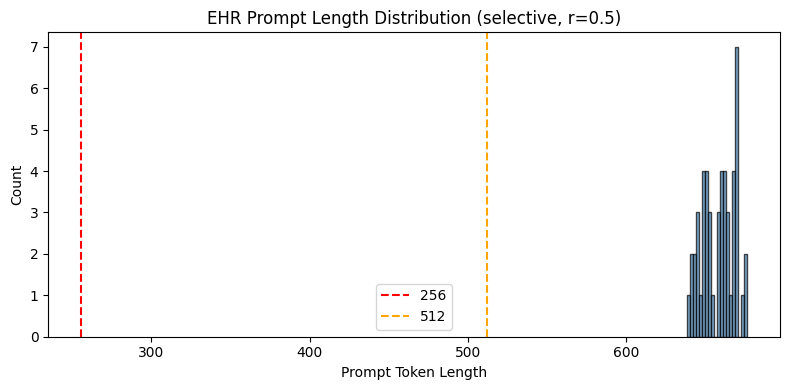

In [10]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Prompt Token Length')
plt.ylabel('Count')
title = f'{DATA_SOURCE.upper()} Prompt Length Distribution'
if DATA_SOURCE == "ehr":
    title += f' ({EHR_STRATEGY}, r={EHR_RETENTION_RATIO})'
plt.title(title)
plt.axvline(x=256, color='r', linestyle='--', label='256')
plt.axvline(x=512, color='orange', linestyle='--', label='512')
plt.legend()
plt.tight_layout()
plt.savefig('../results/prompt_length_dist.png', dpi=150)
plt.show()


In [11]:
groups = split_by_token_length(prompts, tokenizer)
for name, items in groups.items():
    print(f"  {name:8s}: {len(items)} samples")

  short   : 0 samples
  medium  : 0 samples
  long    : 50 samples


In [14]:

# 统一保存为 ehr_prompts.json — 所有后续 notebook 统一从此文件加载
PROMPTS_PATH = '../results/ehr_prompts_llama3.json'
save_prompts(prompts, PROMPTS_PATH)
print(f"Saved → {PROMPTS_PATH}  ({len(prompts)} samples)")
print("后续 notebook 02-06 统一从此 JSON 加载，无需重新生成。")


Saved → ../results/ehr_prompts_llama3.2.json  (50 samples)
后续 notebook 02-06 统一从此 JSON 加载，无需重新生成。
